# Automated Thalweg and Surface Roughness Extraction Pipeline
**Test Area of Interest (AOI):** Koblenz Region, Germany (Bounding Box: 7.55, 50.30, 7.65, 50.40)

## 1. Project Overview
This notebook presents the final output of the automated terrain analysis pipeline. The system executes a fully headless geomorphological extraction process using two primary remote sensing inputs:
1.  **NASADEM (30m Resolution):** Utilized for topographic routing and physical elevation modeling.
2.  **ESA WorldCover 2021 (10m Resolution):** Utilized for categorical land cover extraction.

The primary objective is to compute the main valley thalweg networks via the D8 flow routing algorithm and to derive spatially distributed Manning's n roughness coefficients for subsequent 2D hydrodynamic modeling. All spatial matrices are reprojected to the metric UTM coordinate system (EPSG:32632).

## 2. Methodology

The pipeline utilizes a strict Object-Oriented Programming (OOP) architecture relying on `gdal` for matrix operations and `pysheds` for hydrological routing.

* **Topographic Pre-processing:** The raw NASADEM undergoes a pit-filling operation. Artificial depressions (sinks) in the digital elevation matrix are filled to enforce continuous downward flow.
* **Hydrological Routing (D8):** The algorithm calculates the flow direction by identifying the steepest descent among the 8 adjacent cells. Flow accumulation is then computed. A strict threshold is applied to the accumulation matrix to delineate the primary thalweg network.
* **Surface Roughness Parameterization:** The ESA WorldCover categorical matrix is reclassified into a continuous friction surface representing Manning's roughness coefficient (n). Empirical physical parameters are assigned, ensuring no spatial data gaps (NoData holes). For instance, permanent water bodies (Class 80) are assigned n = 0.030, and urban built-up areas (Class 50) are assigned n = 0.050.

Loading Final Cartographic Visualization...


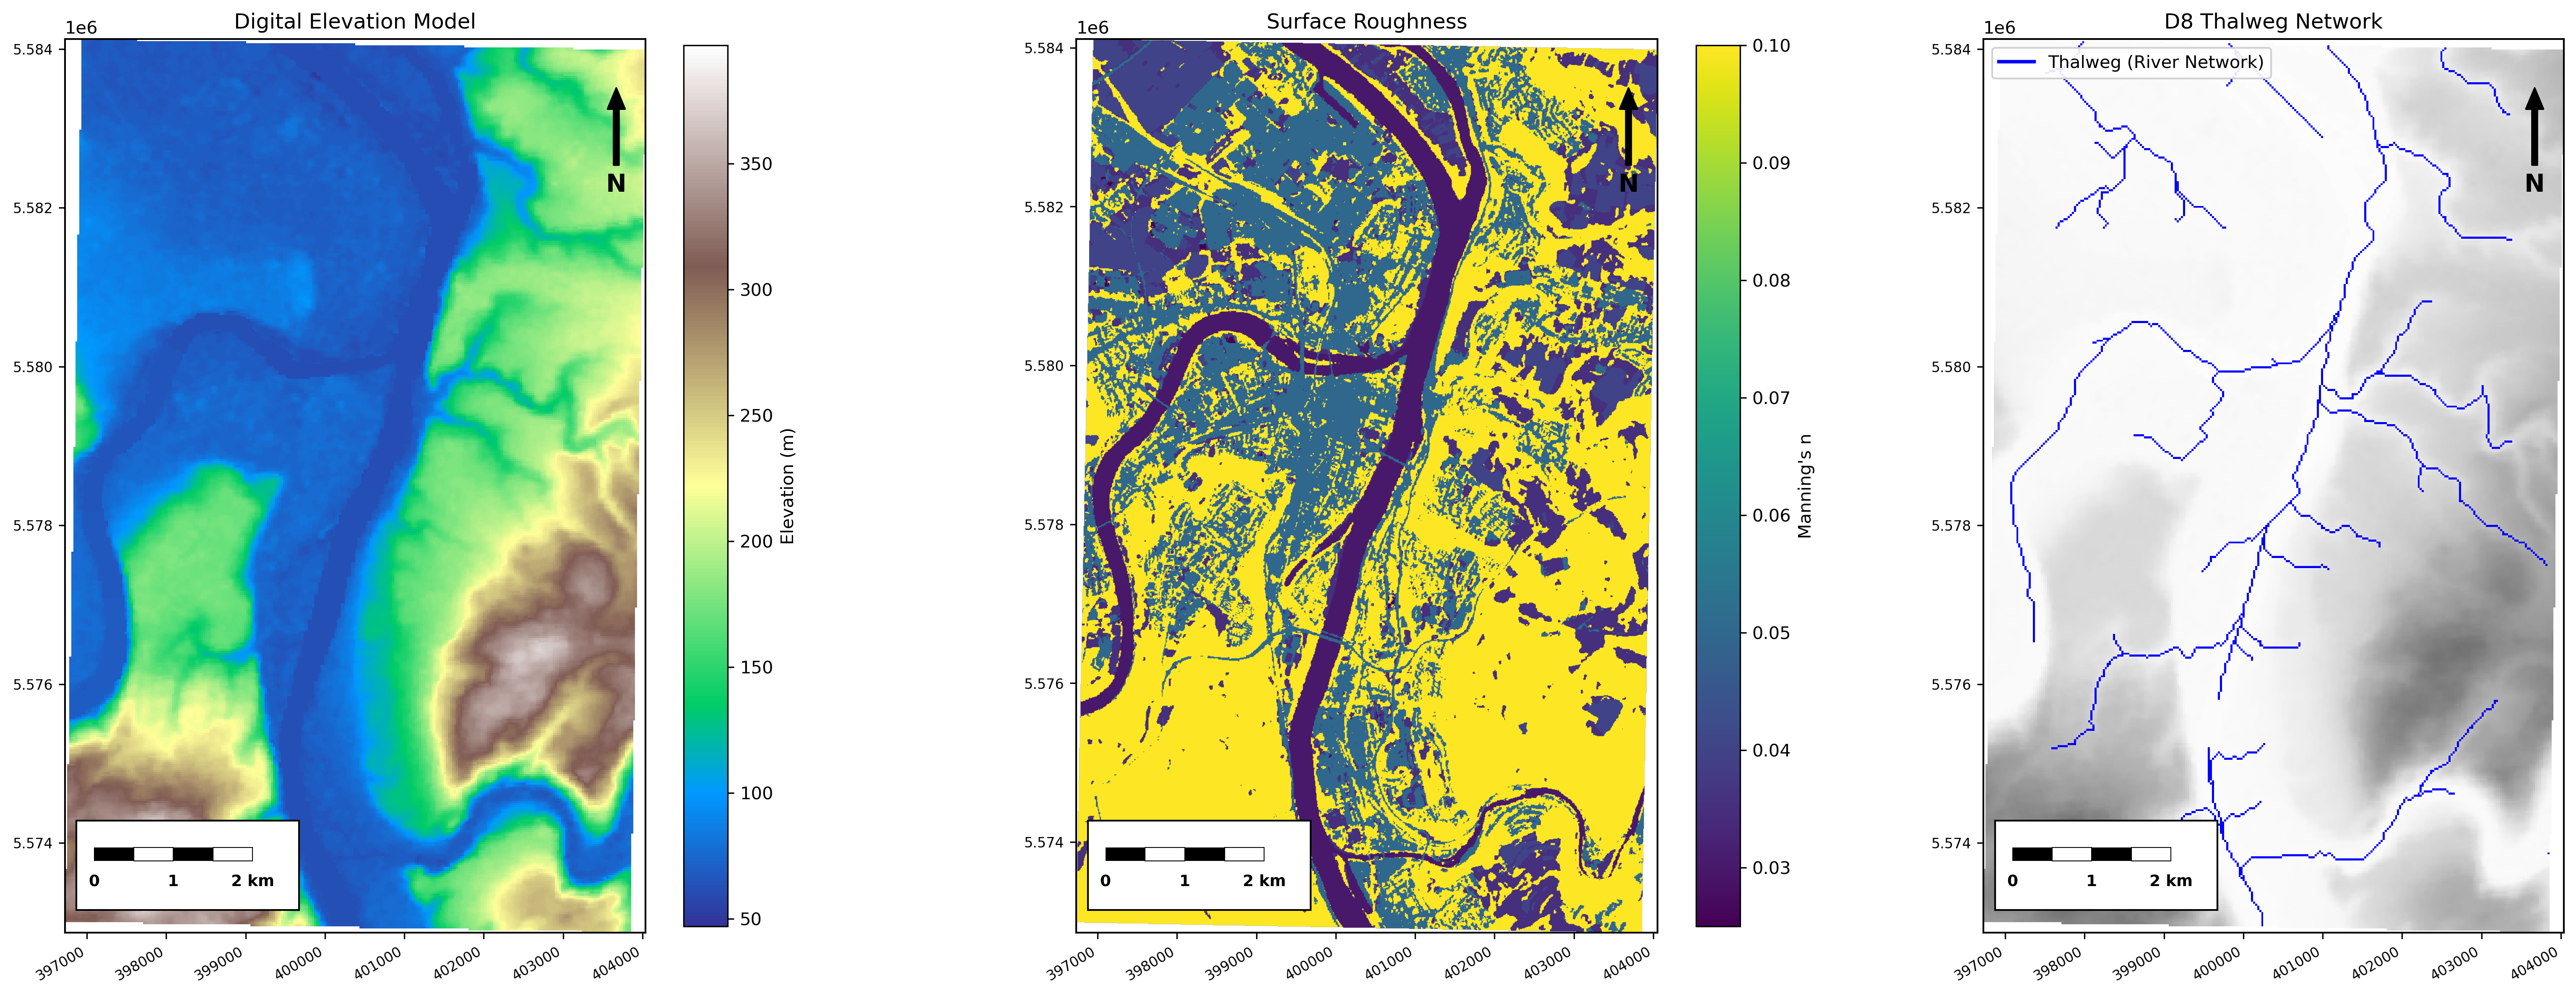

In [1]:
# Standard library imports for visualization within the Jupyter environment
import os
from IPython.display import Image, display

# Define the relative path to the generated cartographic preview map
# This assumes the notebook is executed from within the 'notebooks/' directory
visual_report_path = os.path.join("..", "results", "map_preview.png")

if os.path.exists(visual_report_path):
    print("Loading Final Cartographic Visualization...")
    display(Image(filename=visual_report_path))
else:
    print("Error: The map_preview.png file could not be found.")
    print("Execute 'python terrain_assessment.py --bbox \"7.55,50.30,7.65,50.40\"' in the terminal first.")

## 3. Discussion and Technical Limitations

### 3.1 Parameter Verification in the Koblenz AOI
The generated visual report confirms the structural alignment of the physical parameters. In the Surface Roughness matrix, the spatial boundaries of the Rhine and Moselle rivers are correctly parameterized (n = 0.030), eliminating previous calculation errors caused by unmapped categorical values. The dense urban infrastructure of Koblenz correctly registers higher hydraulic resistance.

### 3.2 Physical Limitations of the D8 Extraction
The D8 algorithm successfully extracted the primary Y-shaped drainage network of the Rhine-Moselle confluence. However, a strict examination of the output reveals a critical physical limitation inherent to the input data:
* **Resolution Constraints and Urban Artifacts:** The 30-meter spatial resolution of the NASADEM captures significant urban infrastructure (e.g., bridge decks crossing the Rhine) as solid topographic barriers rather than passable waterways. 
* **Algorithmic Consequence:** Because the pipeline currently routes flow based purely on surface elevation without employing digital river burning (hydro-enforcement) techniques, the D8 algorithm is forced to route accumulation *around* these artificial obstacles. This causes localized geometric distortions where the extracted thalweg matrix deviates from the true physical centerline of the river.

### 4. Conclusion
The backend architecture successfully achieves total automation. The memory leak vulnerabilities and Windows file locking mechanisms (WinError 32) have been fully resolved via explicit garbage collection tracking. The resulting `thalweg_network.tif` and `roughness.tif` datasets are strictly georeferenced and are structurally ready for external hydrodynamic simulation software.